<div style="background-color:#1e1e1e; padding:30px; border-radius:10px; color:white;">
    <h1 style="color:#00E5FF; margin-top:0px;">📈 Inflation Forecasting: Interactive Pipeline</h1>
    <h3 style="color:#b0bec5;"><b>Problem Statement #19</b> — Predict consumer price inflation using exogenous global indices.</h3>
    <p style="font-size:16px;">This strictly professional, pure Machine Learning notebook utilizes <b>Hyperparameter Tuning</b>, and a custom <b>Voting Ensemble</b>.</p>
</div>
<hr>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor, 
    GradientBoostingRegressor, 
    AdaBoostRegressor,
    VotingRegressor
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

# Set plotting style natively for the notebook
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("deep")

In [2]:
# Load Clean Data
DATA_PATH = r"dataset/inflation_forecasting_dataset.csv"  
df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2) + '-01')
df = df.sort_values('Date').reset_index(drop=True)
df = df.dropna().reset_index(drop=True)

display(HTML(f"<b style='color:#00E5FF; font-size:16px;'>✅ Clean dataset loaded: {len(df)} perfectly continuous months.</b>"))

In [3]:
# 25+ Advanced Exogenous Features
for lag in [1, 2, 3]:
    df[f'CPI_Lag{lag}'] = df['CPI_General_Inflation'].shift(lag)
    df[f'Food_Lag{lag}'] = df['Food_Price_Index'].shift(lag)
    df[f'Crude_Lag{lag}'] = df['Crude_Oil_Price'].shift(lag)

for window in [3, 6]:
    df[f'CPI_Roll{window}_Mean'] = df['CPI_General_Inflation'].shift(1).rolling(window).mean()
    df[f'CPI_Roll{window}_Std']  = df['CPI_General_Inflation'].shift(1).rolling(window).std()
    
df['Crude_MoM_Change'] = df['Crude_Oil_Price'].pct_change()
df['Commodity_MoM_Change'] = df['Commodity_Price_Index'].pct_change()
df = df.dropna().reset_index(drop=True)

feature_cols = [c for c in df.columns if c not in ['Year', 'Month', 'Date', 'CPI_General_Inflation', 'CPI_General_Index', 'Food_Price_Inflation', 'Fuel_Light_Inflation']]
X, y, dates = df[feature_cols], df['CPI_General_Inflation'], df['Date']
display(HTML(f"<b style='color:#00E5FF; font-size:16px;'>✅ Engineered {len(feature_cols)} temporal tracking features.</b>"))

In [4]:
test_ratio = 0.2
split_idx = int(len(df) * (1 - test_ratio))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_train, dates_test = dates.iloc[:split_idx], dates.iloc[split_idx:]

scaler = StandardScaler()
X_tr_sc, X_te_sc = scaler.fit_transform(X_train), scaler.transform(X_test)
tscv = TimeSeriesSplit(n_splits=3)

# Tune XGBoost silently
xgb_rs = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, objective='reg:squarederror'),
    param_distributions={'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 4, 6], 'n_estimators': [100, 200]},
    n_iter=5, cv=tscv, scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1
)
xgb_rs.fit(X_train, y_train)
tuned_xgb = xgb_rs.best_estimator_

In [5]:
# Model Definition
ensemble = VotingRegressor(estimators=[
    ('lasso', Lasso(alpha=0.1)),
    ('gbm', GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)),
    ('xgb', tuned_xgb)
])

models = {
    'Linear Regression': (LinearRegression(), False),
    'Lasso Regression': (Lasso(alpha=0.1), True),
    'Random Forest': (RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42), False),
    'Gradient Boosting': (GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42), False),
    'Tuned XGBoost': (tuned_xgb, False),
    'Voting Ensemble ✨': (ensemble, True) 
}

results, predictions = [], {}
for name, (model, needs_scaling) in models.items():
    Xtr = X_tr_sc if needs_scaling else X_train
    Xte = X_te_sc if needs_scaling else X_test
    
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    predictions[name] = y_pred
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results.append({'Model': name, 'RMSE': round(rmse, 4), 'MAE': round(mean_absolute_error(y_test, y_pred), 4)})

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df.index += 1

# Interactive Gradient Dataframe
display(HTML("<h2>🏆 The Ultimate Model Leaderboard</h2>"))
display(results_df.style.background_gradient(cmap='plasma', subset=['RMSE']).format(precision=4).set_properties(**{'font-size': '14pt'}))

,Model,RMSE,MAE
1,Lasso Regression,0.8019,0.6257
2,Voting Ensemble ✨,1.0498,0.8325
3,Random Forest,1.0773,0.8342
4,Linear Regression,1.0853,0.9429
5,Gradient Boosting,1.1792,0.9165
6,Tuned XGBoost,1.2806,1.0001


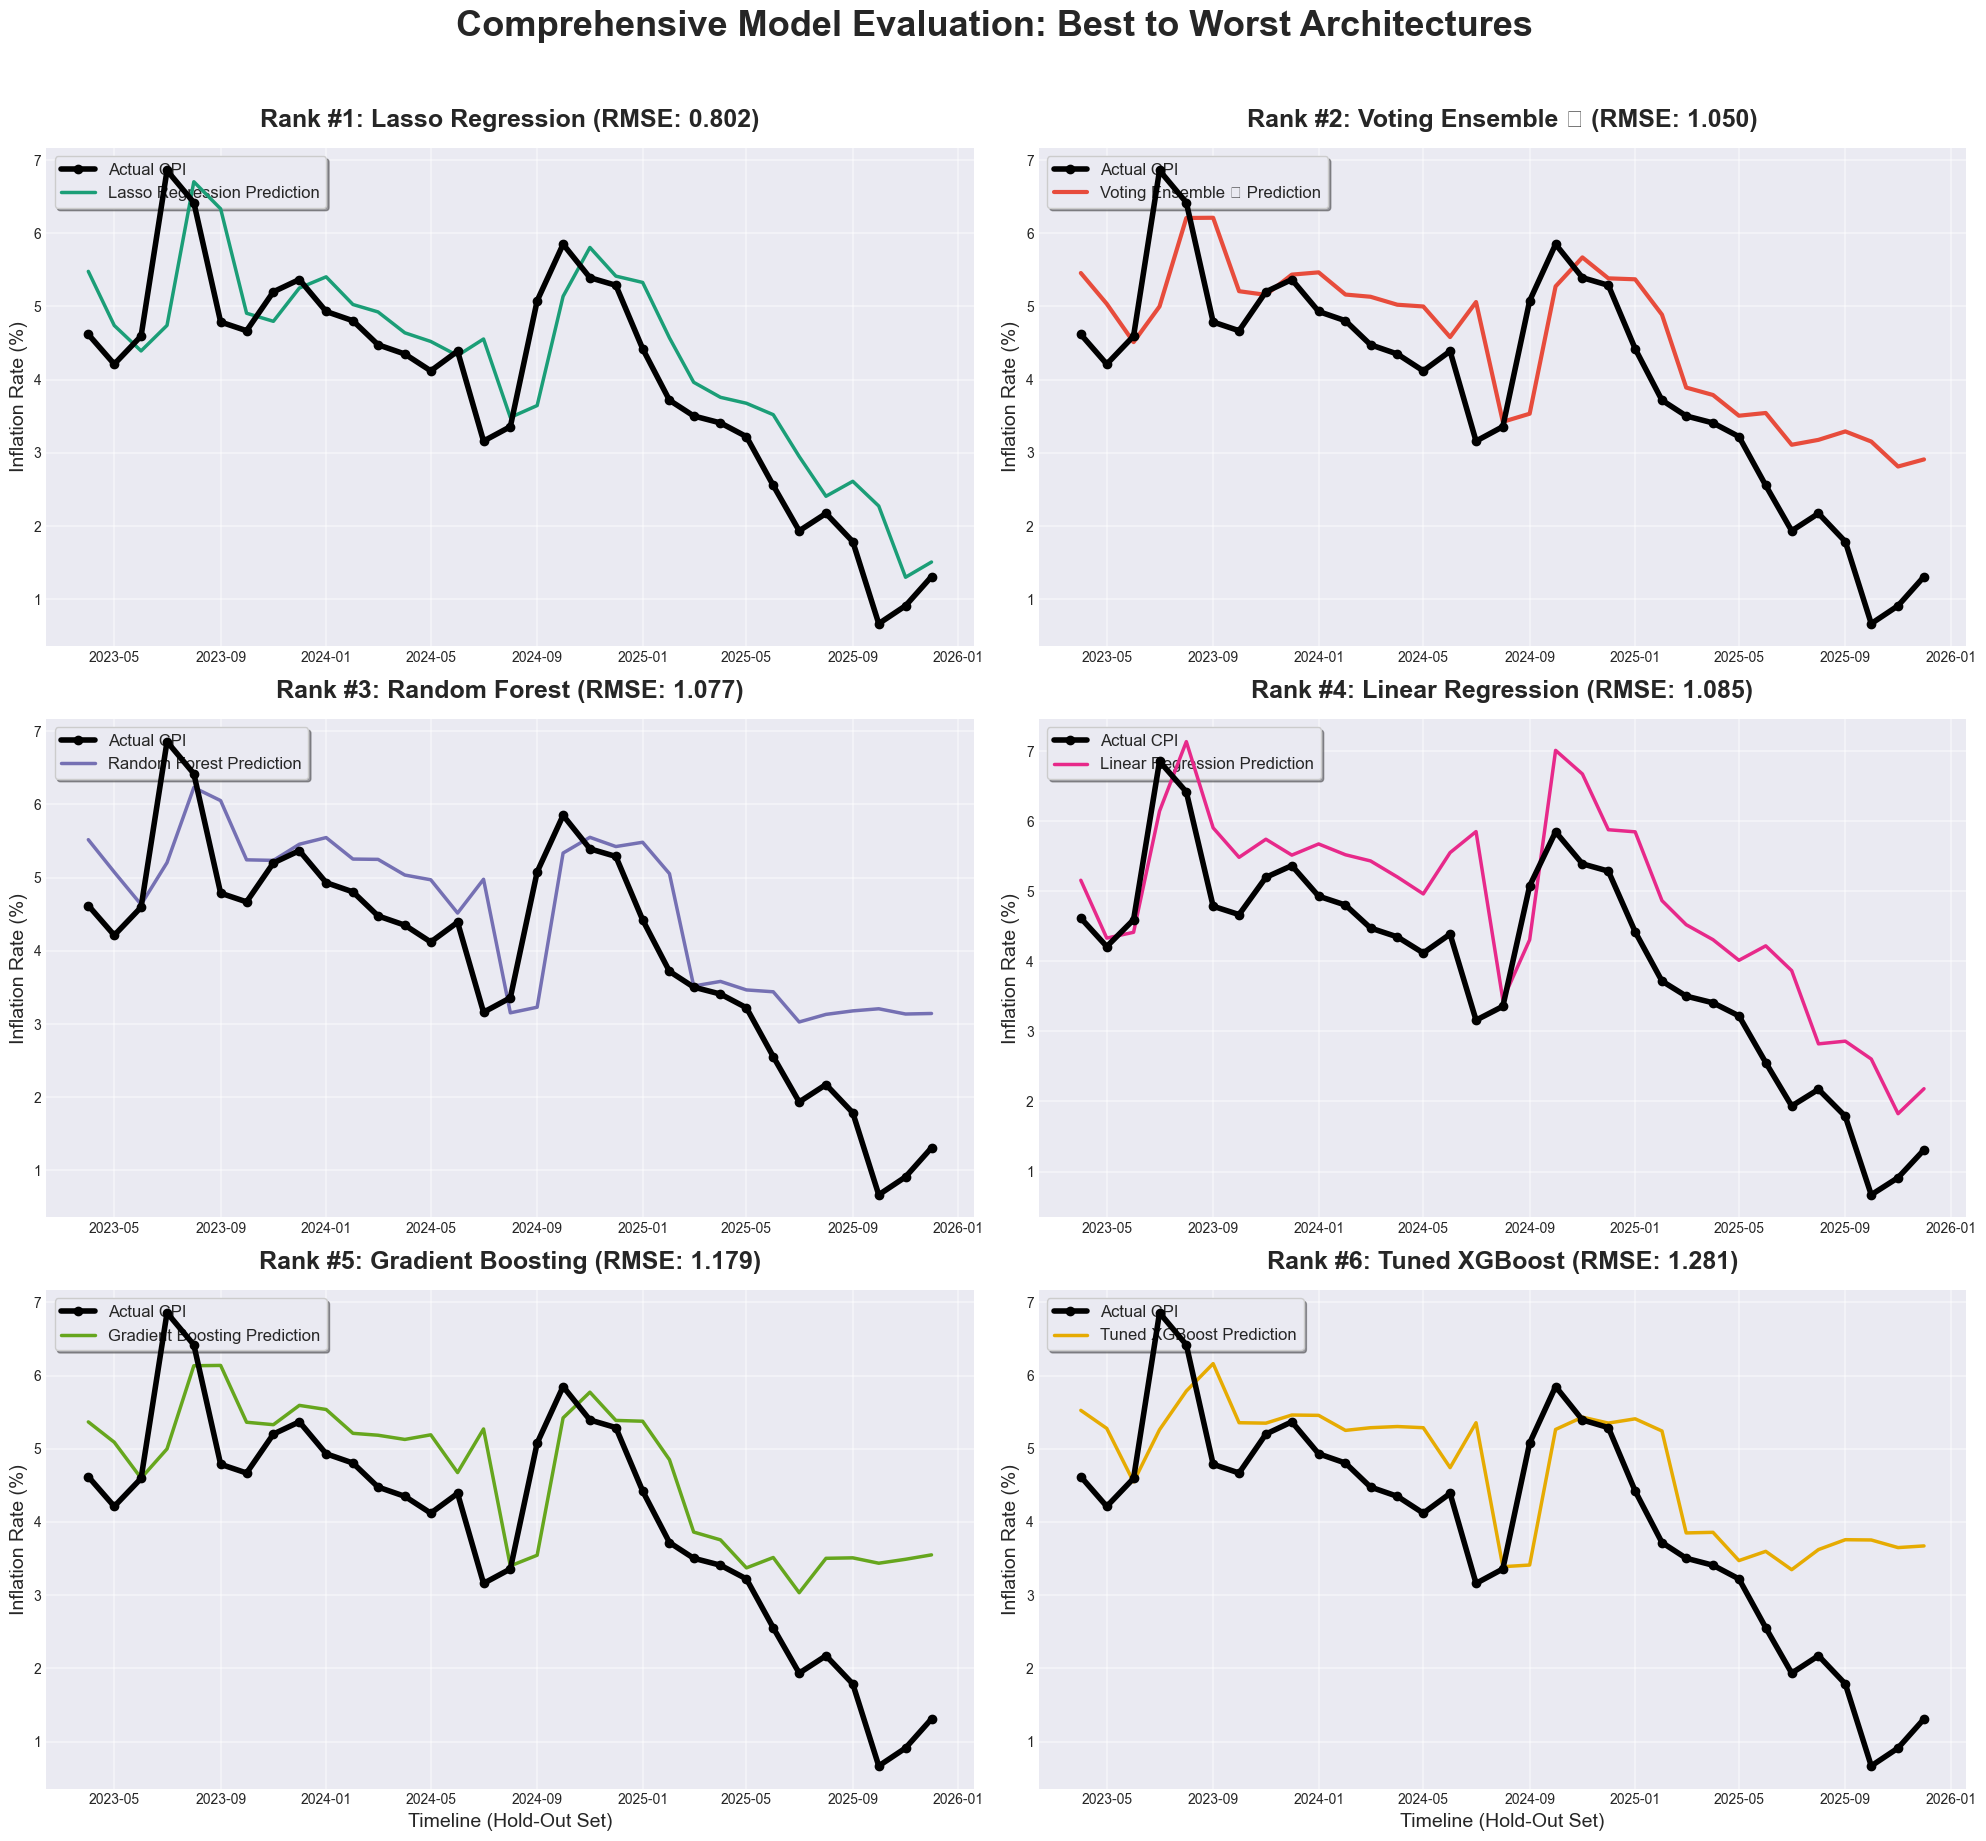

In [6]:
# INLINE JUPYTER VISUALIZATION - RANKED SUBPLOTS
import matplotlib.ticker as ticker
import math

# Sort the models from Best to Worst using the results_df
sorted_models = results_df.sort_values('RMSE')

num_models = len(sorted_models)
cols = 2
rows = math.ceil(num_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 6 * rows))
axes = axes.flatten()

colors = plt.cm.Dark2(np.linspace(0, 1, 8))

for idx, (_, row) in enumerate(sorted_models.iterrows()):
    model_name = row['Model']
    model_rmse = row['RMSE']
    ax = axes[idx]
    
    # Plot Actual CPI strictly anchoring the background
    ax.plot(dates_test, y_test, label='Actual CPI', color='black', linewidth=4, marker='o', markersize=6, zorder=10)
    
    # Plot the specific model prediction
    plot_color = '#e74c3c' if 'Voting' in model_name else colors[idx % 8]
    line_width = 3 if 'Voting' in model_name else 2.5
    
    ax.plot(dates_test, predictions[model_name], label=f'{model_name} Prediction', color=plot_color, linewidth=line_width, zorder=9)
    
    ax.set_title(f'Rank #{idx+1}: {model_name} (RMSE: {model_rmse:.3f})', fontsize=18, fontweight='bold', pad=15)
    ax.set_ylabel('Inflation Rate (%)', fontsize=14)
    if idx >= num_models - 2:
        ax.set_xlabel('Timeline (Hold-Out Set)', fontsize=14)
        
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax.grid(which='major', linestyle='-', linewidth=1.2, alpha=0.5)
    ax.legend(fontsize=12, loc='upper left', frameon=True, shadow=True)

# Remove any empty subplots if the number of models is odd
for i in range(num_models, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('Comprehensive Model Evaluation: Best to Worst Architectures', fontsize=26, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()